In [82]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import xarray as xr
import cartopy.crs as ccrs; from cartopy.util import add_cyclic_point; import cartopy.feature as cfeature
import matplotlib.pyplot as plt

In [25]:
dummy = False # data switch

In [72]:
# --------------------------------------------------------
# Chose which data to work with
# --------------------------------------------------------
if dummy:

    """
    Use a dummy cluster label data with nc = 3, nens = 5, npts = 10
    """
    np.random.seed(42)  # Set seed for reproducibility
    npts = 10
    nens = 5
    nc = 6
    arrays = []
    while len(arrays) < nens:
        arr = np.random.choice([0, 1, 2, 4, 5, 6], size=npts)
        # print(set(arr))
        if len(set(arr)) == 6:  # Ensure all labels 0,1,2,3 are present
            arrays.append(arr)
    lab = np.array(arrays)

else:
    """
    Use real data
    """
    # filename = './nemi_pack_nclust_4_nbr_100_mind_0.0.npy' # this is from idealised-land simulation data; 60S-60N, pentad mean momentum budget
    filename = './test_clusters.npy' # this is from half-land idealised simulation data; 30S-30N, August mean momentum budget
    if os.path.exists(filename):
        lab = np.load(filename)
        print("File loaded successfully.")
        
    else:
        raise FileNotFoundError(f"Error: '{filename}' does not exist. Use dummy=True for dummy data to proceed")    

File loaded successfully.


In [106]:
print(f"NEMI pack shape:'{lab.shape}' ")
print(f"Unique labels:'{np.unique(lab)}' ")
# print(f"Ensemble size:'{lab.shape[0]}' ")
nens = lab.shape[0]
nc = int(np.max(lab))+1
nc

NEMI pack shape:'(5, 2816)' 
Unique labels:'[0. 1. 2. 3. 4. 5. 6. 7. 8.]' 


9

In [74]:
lab

array([[8., 8., 8., ..., 1., 1., 1.],
       [2., 2., 2., ..., 1., 1., 1.],
       [2., 2., 2., ..., 1., 1., 1.],
       [7., 7., 7., ..., 1., 1., 1.],
       [2., 2., 2., ..., 1., 1., 1.]], shape=(5, 2816))

In [89]:
"""
Written by Maike Sonnewald
"""
def get_overlap(ensembles,id=0,n_ens=3,max_clusters=None):


    base_id = id
    base_labels = ensembles[base_id]
    compare_ids = [i for i in range(n_ens)]
    compare_ids.pop(base_id)

    num_clusters = int(np.max(base_labels) + 1)


    # if not pre-set, set max number of clusters to total number of clusters in the base
    if max_clusters is None:
        max_clusters = num_clusters

    sortedOverlap=np.zeros((len(compare_ids)+1, max_clusters, base_labels.shape[0]))*np.nan

    # print(num_clusters, max_clusters)
    summaryStats=np.zeros((num_clusters, max_clusters))

    # compile sorted cluster data
    # TODO: add assert statement to make sure that the clusters have been sorted?


    # dataVector=[nemi.clusters for id, nemi in enumerate(self.nemi_pack) if id != base_id]
    dataVector=[ensembles[id] for id, nemi in enumerate(ensembles) if id != base_id]

    # loop over ensemble members, not including the base member
    for compare_cnt, compare_id in enumerate(compare_ids):
        # grab clusters of ensemble member
        compare_labels= dataVector[compare_cnt]

        # go through each cluster in the base and assess the percentage overlap
        # for every cluster in the ensemble member (overlap / total coverage area) 
        for c1 in range(max_clusters): 
            # Initialize dummy array to mark location of the cluster for the base member
            data1_M = np.zeros(base_labels.shape, dtype=int)
            # mark where the considered cluster is in the member that is being used as the baseline
            data1_M[np.where(c1==base_labels)] = 1 
            # # Count numer of entries [Why?] 
            summaryStats[0, c1]=np.sum(data1_M) 

            # go through each cluster
            # k = 0
            for c2 in range(num_clusters):
                # Initialize dummy array to mark where the cluster is in the comparison member
                data2_M = np.zeros(base_labels.shape, dtype=int) 

                # mark where the considered cluster is in the member that is being used as the comparison
                data2_M[np.where(c2==compare_labels)] = 1    

                # Sum of flags where the two datasets of that cluster are both present
                num_overlap=np.sum(data1_M*data2_M)       

                #Sum of where they overlap
                num_total=np.sum(data1_M | data2_M)       

                #Collect the number that is largest of k and the num_overlap/num_total
                # k = max(k, num_overlap / num_total)       
                summaryStats[c2, c1]=(num_overlap / num_total)*100 # Add percentage of coverage

            #Filled in 'summaryStatistics' matrix results of percentage overlaps

        usedClusters = set() # Used to mak sure clusters don't get selected twice
        #Clusters are already sorted by size
        
        sortedOverlapForOneCluster=np.zeros(base_labels.shape, dtype=int)*np.nan
        # go through clusters from (biggest to smallest since they are sorted)
        for c1 in range(max_clusters):  
            sortedOverlapForOneCluster=np.zeros(base_labels.shape, dtype=int)*np.nan
            #print('cluster number ', c1, summaryStats.shape, summaryStats[1:,c1-1].shape)

            # find biggest cluster in first column, making sure it has not been used
            sortedClusters = np.argsort(summaryStats[:, c1])[::-1]
            biggestCluster = [ele for ele in sortedClusters if ele not in usedClusters][0]

            # record it for later
            usedClusters.add(biggestCluster)

            # Initialize dummy array
            data2_M = np.zeros(base_labels.shape, dtype=int)

            # Select which country is being assessed
            data2_M[np.where(biggestCluster == compare_labels)]=1 # Select cluster being assessed

            sortedOverlapForOneCluster[np.where(data2_M==1)]=1
            sortedOverlap[compare_id, c1, :] = sortedOverlapForOneCluster

    # fill in the base entry in the sorted overlap
    for c1 in range(max_clusters):  
        sortedOverlap[base_id, c1, :] = 1 * (base_labels == c1)

    return  sortedOverlap


In [101]:
sortedOverlap = get_overlap(lab,id=0,n_ens=nens,max_clusters=None) # calculates relabelled clusters for a given base_id
ov = np.nan_to_num(sortedOverlap)
ov.shape

(5, 9, 2816)

In [91]:
"""
creates nice dataframe where rows are sample points and columns are ensembles
values are cluster labels for a given data point and ensemble member
"""
df = pd.DataFrame(np.argmax(ov,axis=1)).T
df = df.astype('int64')
df

,0,1,2,3,4
0,8,3,3,8,3
1,8,3,3,8,3
2,8,3,3,8,3
3,8,3,3,8,3
4,8,2,3,8,3
...,...,...,...,...,...
2811,1,1,1,1,1
2812,1,1,1,1,1
2813,1,1,1,1,1
2814,1,1,1,1,1


In [92]:
"""
sanity check
"""
print(ov[2,:,0]) # gives label index for ens member 2 and data point 0
print(np.argmax(ov,axis=1)[2,0])

[0. 0. 0. 1. 0. 0. 0. 0. 0.]
3


In [93]:
"""
creates a dataframe where count of unique labels are stored for all sample data points
"""

df_c = pd.DataFrame(
    df.stack().groupby(level=0).apply(lambda x: np.unique(x, return_inverse=True, return_counts=True)[2])
)
df_c.columns = ['counts']
df_c

,counts
0,"[3, 2]"
1,"[3, 2]"
2,"[3, 2]"
3,"[3, 2]"
4,"[1, 2, 2]"
...,...
2811,[5]
2812,[5]
2813,[5]
2814,[5]


In [121]:
"""
entropy function
"""

def _entropy(row,i=0):

    data = row['counts']
    L = sum(data)
    n = len(data)
    
    if n != 1:
        ress = 0
        for i in range(n):
            ress =  ress + (data[i]/L * np.log2(data[i]/L))
                            
    else:
                            
        ress = (data[i]/L * np.log2(data[i]/L))
    
    return ress*(-1)


In [122]:
ent =  df_c.apply(_entropy, axis=1) # entropy


In [123]:
"""
calculate theoretical maximum entropy for a given number of clusters
"""

nc = int(lab.max())+1
EntMax = (-1) * nc * (1/nc) * np.log2(1/nc)

In [124]:
entropy = np.asanyarray((ent * 100)/EntMax)

<Axes: ylabel='Count'>

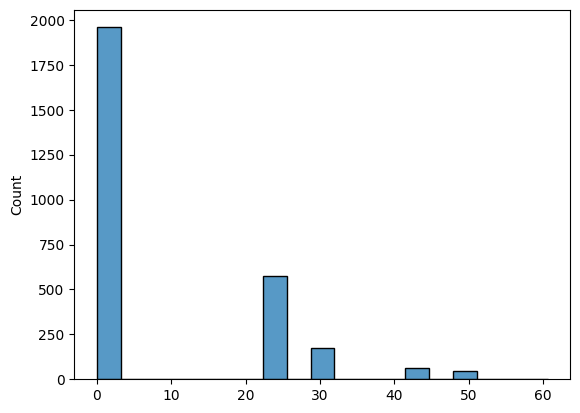

In [125]:
sns.histplot(entropy)

## Let's plot the intermediate steps that facilitate relabelling and final NEMI assignment

In [126]:
# create xarray data 
ds = xr.open_dataset('/mnt/c/Users/duttaay/OneDrive - University of Birmingham/codes/nemi_forked/NEMI/nemi/nemi_clusters_nclust_4_5_0.0_hac_knn_40.nc')
ds = ds.sel(lat=slice(-30,30))
lat = ds.lat 
lon = ds.lon
nlat = len(lat); nlon = len(lon)
ov_xr = np.reshape(ov,[nens,nc,nlat,nlon])
ov_xr = xr.DataArray(ov_xr,coords={'ens':range(nens),'nc':range(nc),'lat':lat,'lon':lon})

Text(0.5, 0.93, 'sortedOverlap[ensemble, cluster, location]')

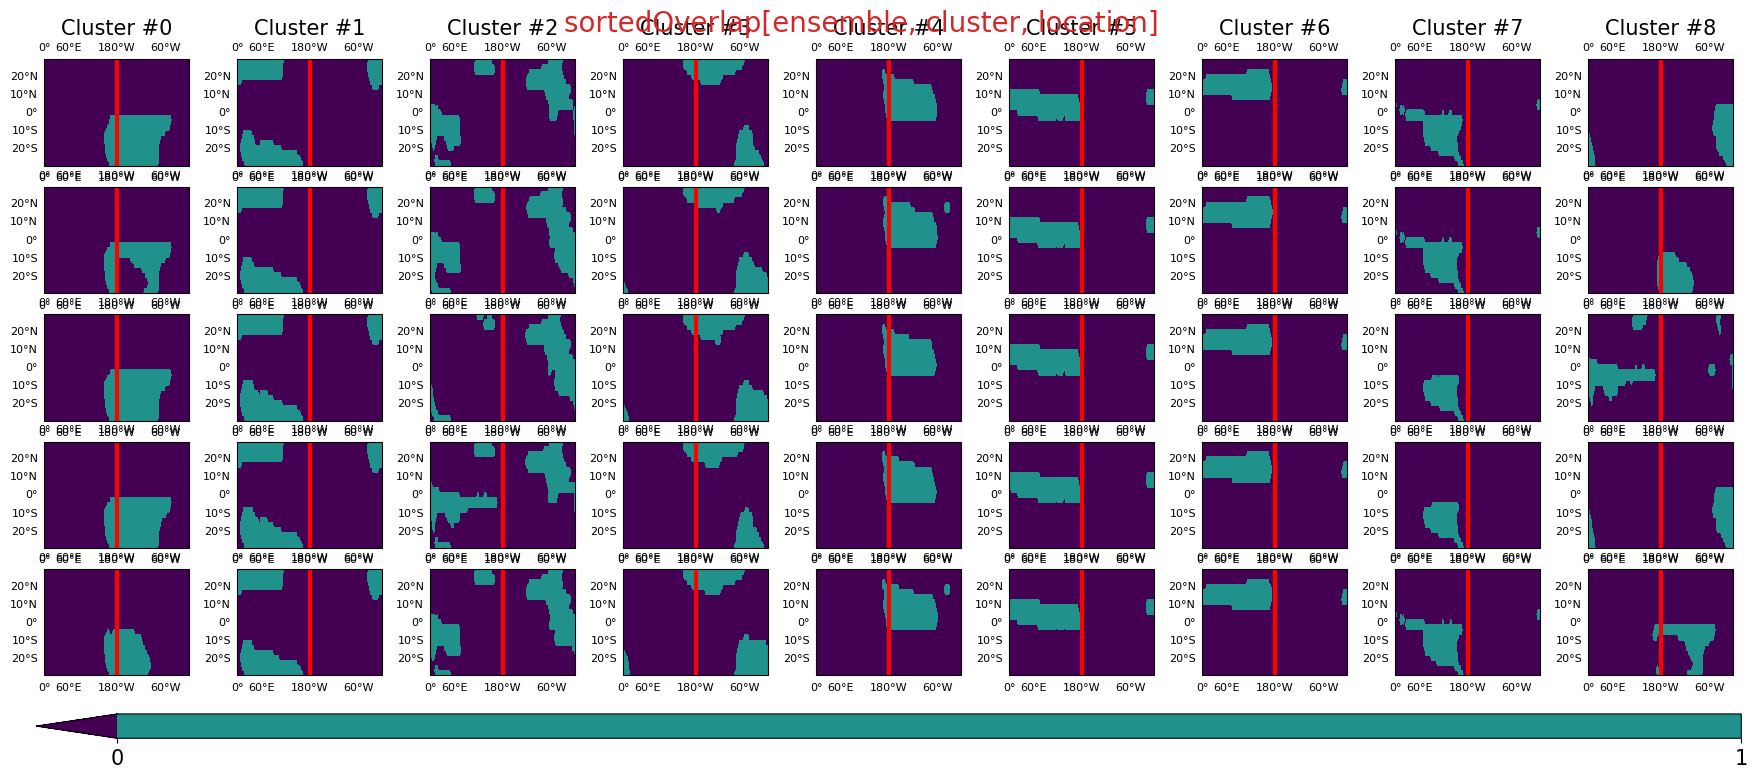

In [127]:


colr = plt.cm.bwr
colr = plt.cm.RdBu_r

# colr = plt.cm.coolwarm
# colr = plt.cm.get_cmap('seismic')
colr = plt.cm.tab20

clevs = np.arange(0,9,1)
clevs = np.arange(0,2,1)
# clevs = None
projection=ccrs.PlateCarree(central_longitude=180)
# projection = ccrs.Robinson(central_longitude=188)
fig, ax = plt.subplots(5,9,figsize=(22,10),subplot_kw=dict(projection=projection),squeeze=False)


i = 0
for j in range(5):
    for k in range(9):
        p = 0
        ax[j][k].set_aspect(4.5)

        import matplotlib.ticker as mticker
        from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
        gl = ax[j][k].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                            linewidth=2, color='gray', alpha=0.5, linestyle='--')
        gl.xlabels_top = False
        gl.ylabels_right = False
        gl.xlines = False
        gl.ylines = False
        gl.ylabels_left = True
        gl.xlabels_bottom = True
        # gl.xlocator = mticker.FixedLocator([65,80,95])
        # gl.ylocator = mticker.FixedLocator([25,`45,65])
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'size': 8, 'color': 'black'}
        gl.ylabel_style = {'size': 8, 'color': 'black'}
        import cartopy.feature as cfeature
        data = ov_xr[j,k]#.fillna(0)
        lon1 = data.lon
        lat1 = data.lat
        data, lon1 = add_cyclic_point(data, coord=lon1)
        cs = ax[j][k].contourf(lon1, lat1, data, levels=clevs, transform=ccrs.PlateCarree(),extend='min')    
        
        ax[j][k].axvline(0,color='red',linewidth=3)

        p += 1
        i += 1

p = 0
for k in range(9):
    ax[0][k].set_title('Cluster #'+str(p),size=15)
    p += 1
    
cbar = fig.colorbar(cs,  ax=ax.ravel().tolist(),orientation='horizontal',aspect=70,pad=0.05)
cbar.ax.tick_params(labelsize=15) 


plt.suptitle('sortedOverlap[ensemble, cluster, location]',color='tab:red',y=0.93,size=20)


#### In the above figure rows (ensemble members) 1-4 are relabelled with reference to 0th row or 0th ensemble. It is interesting to note cluster #8 in ensemble member 2 should have been cluster #0 from looking at it however that region has maximum maximum overlap with cluster #8 of 0th ensemble member and hence relabelled accordingly. Note a similar instance for the last member. And as will be shown later this created artificial entropy over that region. This is a demonstation of how NEMI overestimates uncertainty.

## In the next step let's visualise the majority vote step

In [132]:
aggOverlaps = np.nansum(sortedOverlap,axis=0)
voteOverlaps = np.argmax(aggOverlaps,axis=0)
aggOverlaps_xr = np.reshape(aggOverlaps,[nc,nlat,nlon])
aggOverlaps_xr = xr.DataArray(aggOverlaps_xr,coords={'nc':range(nc),'lat':lat,'lon':lon})

Text(0.5, 0.68, 'aggOverlaps = np.nansum(sortedOverlap,axis=0)')

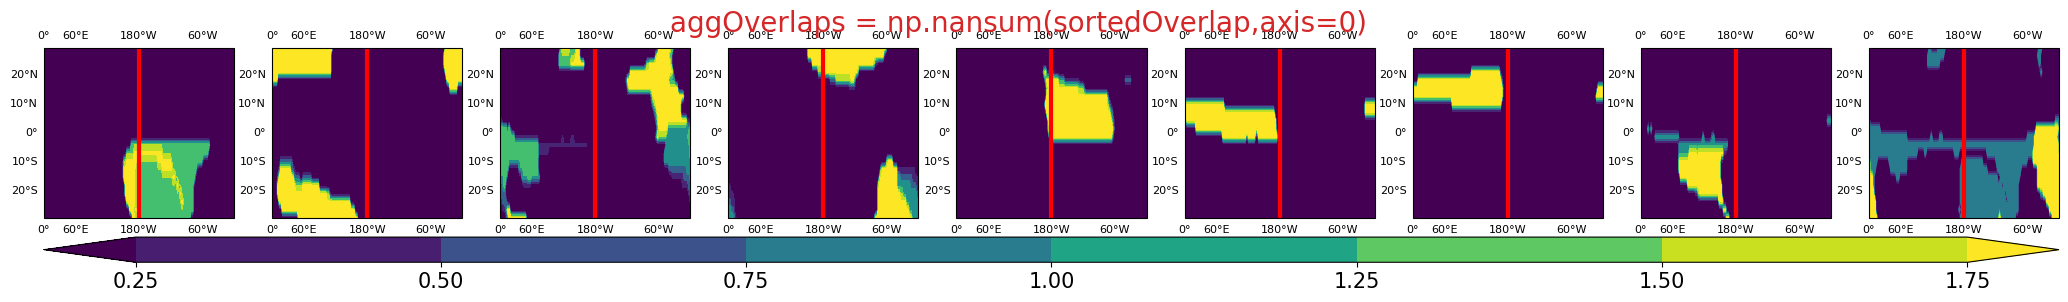

In [135]:


colr = plt.cm.bwr
colr = plt.cm.RdBu_r

# colr = plt.cm.coolwarm
# colr = plt.cm.get_cmap('seismic')
colr = plt.cm.tab20

clevs = np.arange(0,9,1)
clevs = np.arange(0,nens+1,1)
clevs = None
projection=ccrs.PlateCarree(central_longitude=180)
# projection = ccrs.Robinson(central_longitude=188)
fig, ax = plt.subplots(1,9,figsize=(26,5),subplot_kw=dict(projection=projection),squeeze=False)


i = 0
for j in range(9):

    ax[0][j].set_aspect(5.5)


    import matplotlib.ticker as mticker
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl = ax[0][j].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                        linewidth=2, color='gray', alpha=0.5, linestyle='--')
    gl.xlabels_top = False
    gl.ylabels_right = False
    gl.xlines = False
    gl.ylines = False
    gl.ylabels_left = True
    gl.xlabels_bottom = True

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8, 'color': 'black'}
    gl.ylabel_style = {'size': 8, 'color': 'black'}
    import cartopy.feature as cfeature


    data = aggOverlaps_xr[j]
    # data = data * 100
    lon1 = data.lon
    lat1 = data.lat
    data, lon1 = add_cyclic_point(data, coord=lon1)
    cs = ax[0][j].contourf(lon1, lat1, data, levels=clevs, cmap=None, transform=ccrs.PlateCarree(),extend='both')    
    
    ax[0][j].axvline(0,color='red',linewidth=3)

    i += 1
    
cbar = fig.colorbar(cs,  ax=ax.ravel().tolist(),orientation='horizontal',aspect=80,pad=0.05)
cbar.ax.tick_params(labelsize=15) 

plt.suptitle('aggOverlaps = np.nansum(sortedOverlap,axis=0)',color='tab:red',y=0.68,size=20)


#### Figure above shows maximum matching for individual cluster labels across the ensemble members
## In the next step we use majority vote to achieve the final NEMI cluster assignment

In [140]:
voteOverlaps = np.argmax(aggOverlaps,axis=0)
voteOverlaps_xr = np.reshape(voteOverlaps,[nlat,nlon])
voteOverlaps_xr = xr.DataArray(voteOverlaps_xr,coords={'lat':lat,'lon':lon})
voteOverlaps_xr

<xarray.DataArray (lat: 22, lon: 128)> Size: 23kB
array([[3, 3, 3, ..., 3, 3, 3],
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 2, ..., 3, 3, 3],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(22, 128))
Coordinates:
  * lat      (lat) float64 176B -29.3 -26.51 -23.72 -20.93 ... 23.72 26.51 29.3
  * lon      (lon) float64 1kB 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2

In [162]:
def plot_map(da):

    import numpy as np
    import matplotlib 
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    nc = da.max()
    clevs = np.arange(0,nc+1,1)
    
    fig = plt.figure(figsize=(15, 9.5))
    proj = ccrs.PlateCarree(central_longitude=180)
    asp = 2.5
    ax1 = plt.subplot(231, projection=proj,aspect=asp)
    
    cm = plt.cm.Spectral_r
    cm = plt.cm.tab10
    
    f1 = da.plot(ax=ax1,levels=clevs,transform=ccrs.PlateCarree(),add_colorbar=False,extend='max',cmap=cm)
    
    import matplotlib.ticker as mticker
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                        linewidth=1, color='black', alpha=0.2, linestyle='--')
    
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    
    gl.xlines = True
    gl.ylines = True
    
    gl.left_labels = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12, 'color': 'black'}
    gl.ylabel_style = {'size': 12, 'color': 'black'}    
    
    
    cbar=fig.colorbar(f1, ax=[ax1], use_gridspec=True, orientation = 'horizontal',fraction=0.15, pad=0.08, aspect=40, shrink=1)

    
    plt.axvline(0,color='black',linewidth=2)
    plt.title('NEMI clusters')

    print(clevs)

[0 1 2 3 4 5 6 7]


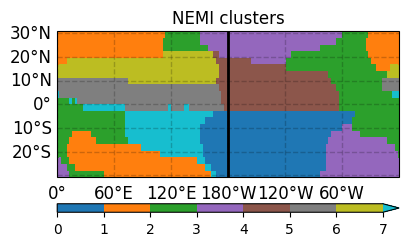

In [163]:
plot_map(voteOverlaps_xr)

## Now let's explore sensitivity on $base\_id$ i.e., reference cluster label used to relabel other ensemble members

In [165]:
nc = int(lab.max())+1
def entropy_for_baseids(bid):
    sortedOverlap = get_overlap(lab,id=bid,n_ens=nens,max_clusters=None) # calculates relabelled clusters for a given base_id
    ov = np.nan_to_num(sortedOverlap)
    df = pd.DataFrame(np.argmax(ov,axis=1)).T
    df = df.astype('int64')
    df_c = pd.DataFrame(
        df.stack().groupby(level=0).apply(lambda x: np.unique(x, return_inverse=True, return_counts=True)[2])
    )
    df_c.columns = ['counts']
    ent =  df_c.apply(_entropy, axis=1) # entropy
    EntMax = (-1) * nc * (1/nc) * np.log2(1/nc)
    entropy = np.asanyarray((ent * 100)/EntMax)
    return entropy

In [166]:
%%time
ent_bid = []
for bid in range(nens):
    ent_bid.append(entropy_for_baseids(bid))

CPU times: user 1 s, sys: 0 ns, total: 1 s
Wall time: 1 s


In [170]:
ar = np.array(ent_bid)
mean = np.mean(ar, axis=0)      
std = np.std(ar, axis=0)

In [175]:
mean_xr = np.reshape(mean,[nlat,nlon])
mean_xr = xr.DataArray(mean_xr,coords={'lat':lat,'lon':lon})

std_xr = np.reshape(std,[nlat,nlon])
std_xr = xr.DataArray(std_xr,coords={'lat':lat,'lon':lon})

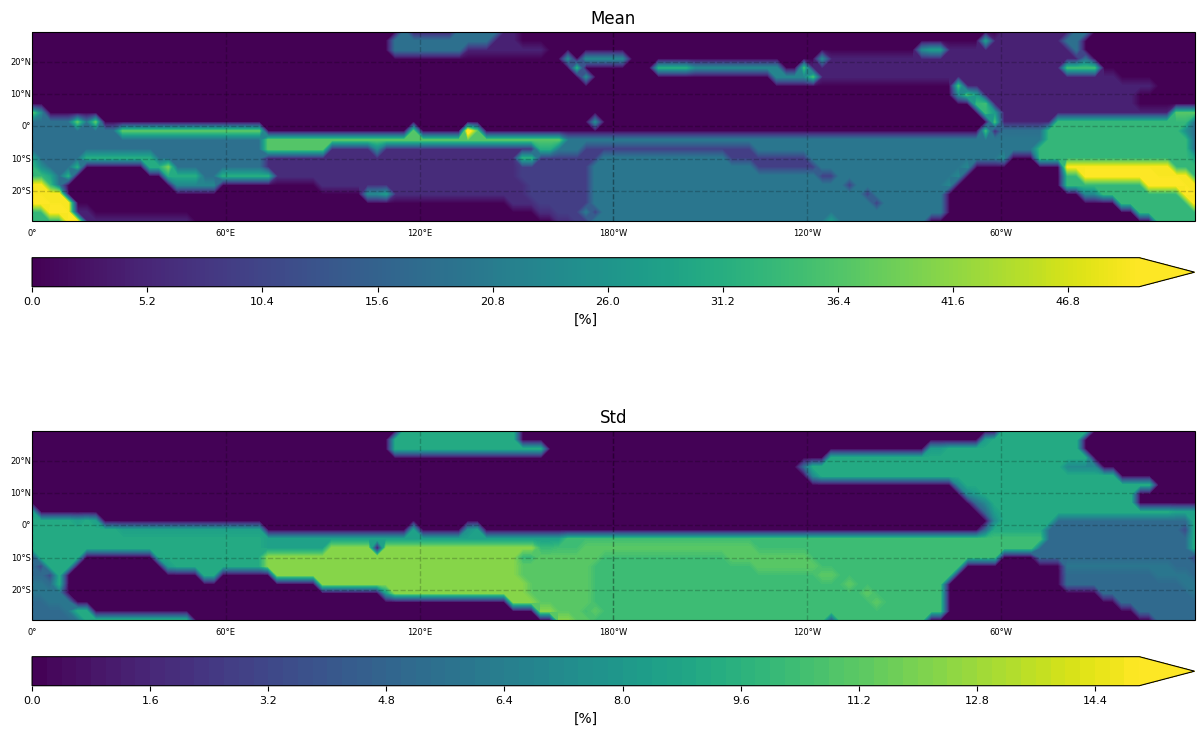

In [226]:
fig,ax = plt.subplots(2,1,subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)),figsize=(15, 9.5))

data = mean_xr
lon1 = data.lon
lat1 = data.lat
data, lon1 = add_cyclic_point(data, coord=lon1)
cs1 = ax[0].contourf(lon1, lat1, data, levels=np.arange(0,50.2,0.2), cmap=None, transform=ccrs.PlateCarree(),extend='max')    

data = std_xr
lon2 = data.lon
lat2 = data.lat
data, lon2 = add_cyclic_point(data, coord=lon2)
cs2 = ax[1].contourf(lon2, lat2, data, levels=np.arange(0,15.2,0.2), transform=ccrs.PlateCarree(),extend='max')    

for axs in ax:
    import matplotlib.ticker as mticker
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
    gl = axs.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                        linewidth=1, color='black', alpha=0.2, linestyle='--')
    
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = True
    
    gl.xlines = True
    gl.ylines = True
    
    gl.left_labels = True
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 6, 'color': 'black'}
    gl.ylabel_style = {'size': 6, 'color': 'black'}        

ax[0].set_title('Mean')
ax[1].set_title('Std')
cb1 = fig.colorbar(cs1, ax=[ax[0]], use_gridspec=True, orientation = 'horizontal',fraction=0.15, pad=0.11, aspect=40, shrink=1)    
cb2 = fig.colorbar(cs2, ax=[ax[1]], use_gridspec=True, orientation = 'horizontal',fraction=0.15, pad=0.11, aspect=40, shrink=1)    
cb1.set_label('[%]')
cb2.set_label('[%]')
cb1.ax.tick_params(labelsize=8)
cb2.ax.tick_params(labelsize=8)

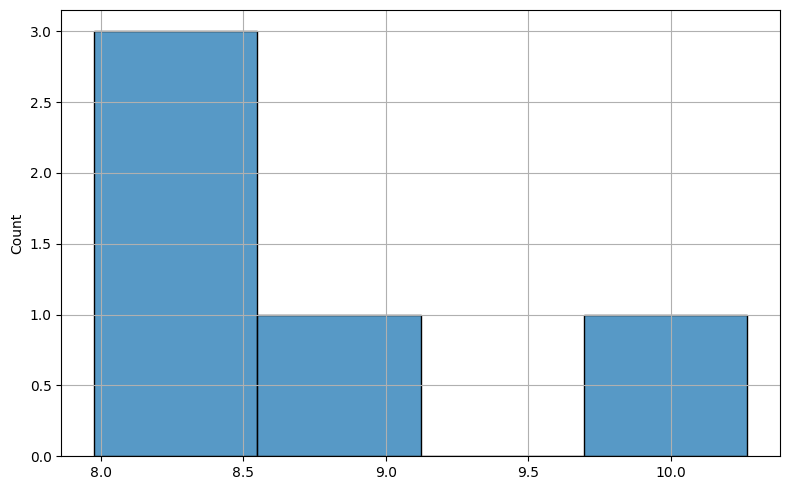

In [227]:
plt.figure(figsize=(8, 5))
# plt.hist(ar.flatten(), bins=50, alpha=0.7, color='green')
# sns.kdeplot(ar.flatten())
sns.histplot(ar.mean(axis=1))
# plt.xlabel("Entropy[%]")
# plt.ylabel("PDF")
# plt.title("Entropy distribution across ensemble members")
plt.grid(True)
plt.tight_layout()
plt.show()


In [230]:
ar.std(axis=1)

array([13.25445021, 13.86926427, 14.97398887, 12.87952813, 13.80632724])